Epoch 001/500 | Train Loss: 0.4293 | Train Acc: 0.8083 | Test Loss: 0.2170 | Test Acc: 0.9394 | Grad Norm: 1.0916
Epoch 025/500 | Train Loss: 0.0066 | Train Acc: 1.0000 | Test Loss: 0.0066 | Test Acc: 1.0000 | Grad Norm: 0.2063
Epoch 050/500 | Train Loss: 0.0022 | Train Acc: 1.0000 | Test Loss: 0.0022 | Test Acc: 1.0000 | Grad Norm: 0.0877
Epoch 075/500 | Train Loss: 0.0013 | Train Acc: 1.0000 | Test Loss: 0.0013 | Test Acc: 1.0000 | Grad Norm: 0.0444
Epoch 100/500 | Train Loss: 0.0009 | Train Acc: 1.0000 | Test Loss: 0.0009 | Test Acc: 1.0000 | Grad Norm: 0.0344
Epoch 125/500 | Train Loss: 0.0007 | Train Acc: 1.0000 | Test Loss: 0.0007 | Test Acc: 1.0000 | Grad Norm: 0.0298
Epoch 150/500 | Train Loss: 0.0005 | Train Acc: 1.0000 | Test Loss: 0.0005 | Test Acc: 1.0000 | Grad Norm: 0.0196
Epoch 175/500 | Train Loss: 0.0004 | Train Acc: 1.0000 | Test Loss: 0.0004 | Test Acc: 1.0000 | Grad Norm: 0.0185
Epoch 200/500 | Train Loss: 0.0004 | Train Acc: 1.0000 | Test Loss: 0.0004 | Test Acc: 1

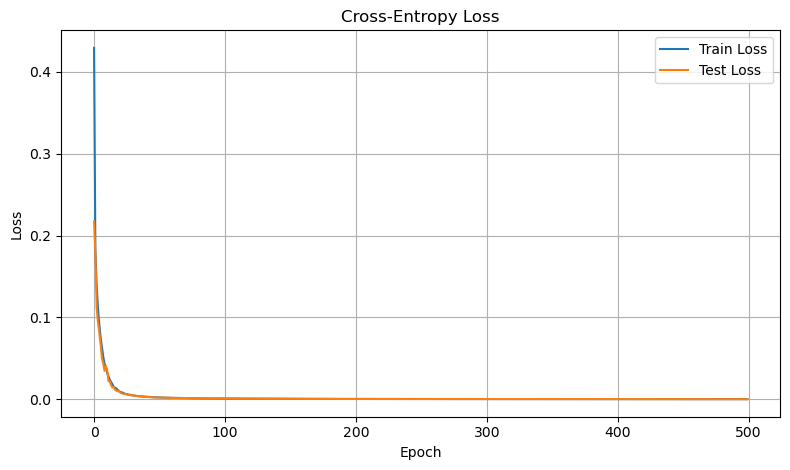

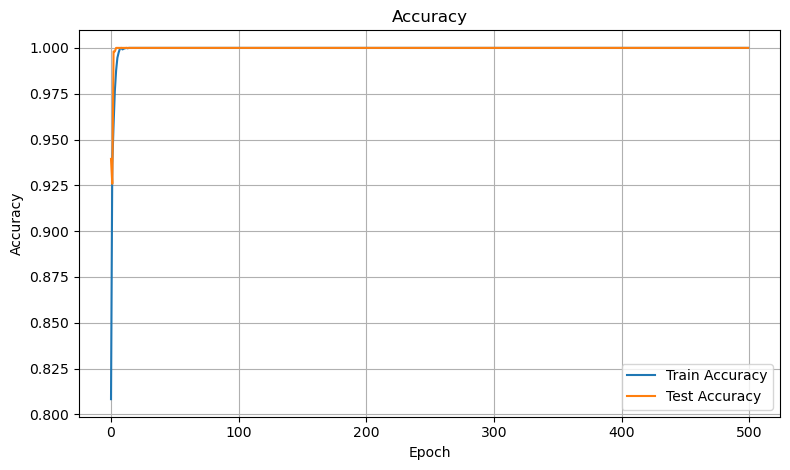

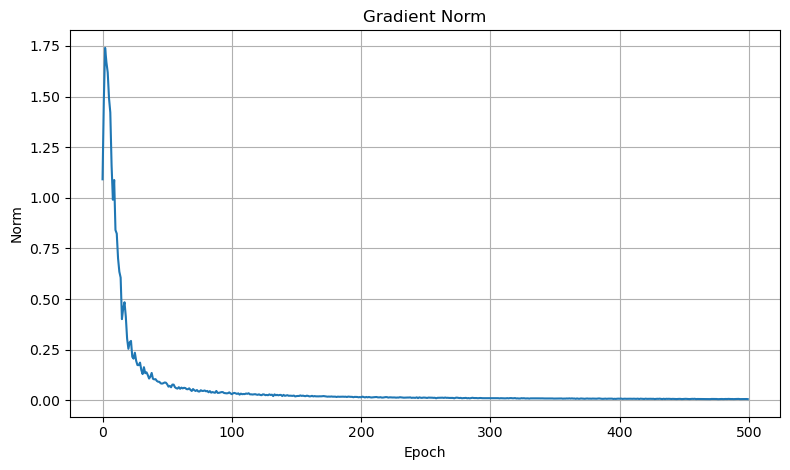

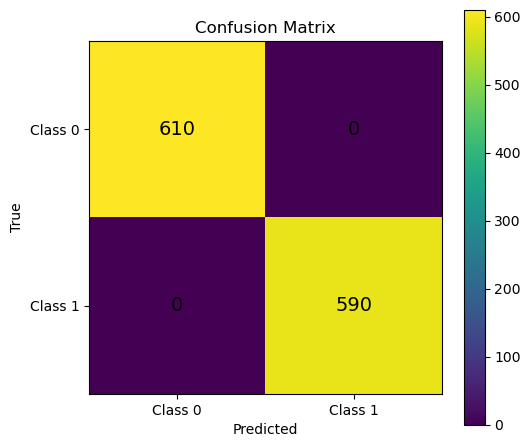

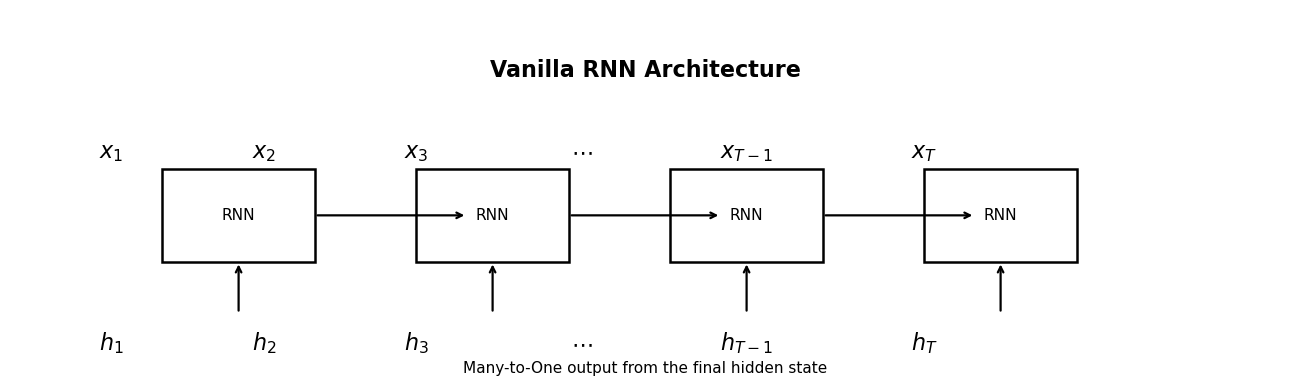


Sample predictions:
Sequence: [0 0 0 0 0 1 0 1 1] | True: 0 | Pred: 0 | Prob: [9.99999313e-01 6.87482792e-07]
Sequence: [1 1 0 1 0 0 0 1 1] | True: 1 | Pred: 1 | Prob: [4.39446029e-04 9.99560554e-01]
Sequence: [1 0 0 0 0 1 0 1 0] | True: 0 | Pred: 0 | Prob: [9.99999998e-01 1.66322854e-09]
Sequence: [1 1 0 0 1 0 0 1 1] | True: 1 | Pred: 1 | Prob: [5.12717445e-04 9.99487283e-01]
Sequence: [1 0 1 1 0 1 0 0 1] | True: 1 | Pred: 1 | Prob: [3.34008709e-04 9.99665991e-01]
Sequence: [1 1 1 1 0 1 0 1 1] | True: 1 | Pred: 1 | Prob: [2.16710404e-11 1.00000000e+00]
Sequence: [0 0 0 1 1 0 1 0 0] | True: 0 | Pred: 0 | Prob: [1.00000000e+00 4.90887041e-10]
Sequence: [1 0 1 0 1 1 1 0 1] | True: 1 | Pred: 1 | Prob: [2.55473568e-09 9.99999997e-01]
Sequence: [1 1 0 0 0 1 1 1 0] | True: 1 | Pred: 1 | Prob: [1.86288587e-05 9.99981371e-01]
Sequence: [1 0 1 1 0 1 1 1 0] | True: 1 | Pred: 1 | Prob: [1.33573599e-08 9.99999987e-01]

Done. Saved figures: m1.png, m2.png, m3.png, m4.png, m5.png


In [1]:
# ============================================================
# Vanilla RNN from Scratch
# Batched Processing + BPTT + Gradient Clipping
# Stable version for 500 epochs on CPU
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ============================================================
# Utility functions
# ============================================================

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / (np.sum(exp_x, axis=1, keepdims=True) + 1e-12)

def cross_entropy_loss(probs, labels):
    batch_size = labels.shape[0]
    eps = 1e-12
    return -np.mean(np.log(probs[np.arange(batch_size), labels] + eps))

def accuracy(probs, labels):
    preds = np.argmax(probs, axis=1)
    return np.mean(preds == labels)

def one_hot(labels, num_classes):
    y = np.zeros((labels.shape[0], num_classes), dtype=np.float64)
    y[np.arange(labels.shape[0]), labels] = 1.0
    return y

def xavier_uniform(shape, rng):
    fan_in, fan_out = shape
    limit = np.sqrt(6.0 / (fan_in + fan_out))
    return rng.uniform(-limit, limit, size=shape)

def orthogonal_matrix(dim, rng):
    a = rng.normal(0.0, 1.0, size=(dim, dim))
    q, r = np.linalg.qr(a)
    # Make Q deterministic in sign
    d = np.diag(r)
    ph = np.sign(d)
    q = q * ph
    return q

# ============================================================
# Dataset
# ============================================================

def generate_dataset(num_samples=6000, seq_len=9, task="majority", seed=123):
    """
    task:
        - "majority" : label = 1 if number of ones >= ceil(seq_len/2)
        - "parity"   : label = 1 if number of ones is odd
    """
    rng = np.random.default_rng(seed)
    X = rng.integers(0, 2, size=(num_samples, seq_len, 1)).astype(np.float64)
    ones_count = np.sum(X, axis=(1, 2)).astype(np.int64)

    if task == "majority":
        threshold = seq_len // 2 + 1
        y = (ones_count >= threshold).astype(np.int64)
    elif task == "parity":
        y = (ones_count % 2).astype(np.int64)
    else:
        raise ValueError("task must be 'majority' or 'parity'")

    return X, y

def train_test_split(X, y, train_ratio=0.8, seed=7):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(X))
    rng.shuffle(idx)
    split = int(len(X) * train_ratio)
    train_idx = idx[:split]
    test_idx = idx[split:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def batch_iterator(X, y, batch_size=64, shuffle=True, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(X))
    if shuffle:
        rng.shuffle(idx)
    for start in range(0, len(X), batch_size):
        batch_idx = idx[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]

# ============================================================
# Vanilla RNN
# ============================================================

class VanillaRNN:
    def __init__(self, input_dim, hidden_dim, output_dim, seq_len, seed=1):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.seq_len = seq_len

        rng = np.random.default_rng(seed)

        # Combined matrix for [x_t, h_{t-1}]
        self.W_combined = np.zeros((input_dim + hidden_dim, hidden_dim), dtype=np.float64)

        # Input block: Xavier
        self.W_combined[:input_dim, :] = xavier_uniform((input_dim, hidden_dim), rng)

        # Recurrent block: orthogonal for stability
        self.W_combined[input_dim:, :] = 0.9 * orthogonal_matrix(hidden_dim, rng)

        self.b_h = np.zeros((1, hidden_dim), dtype=np.float64)

        self.W_out = xavier_uniform((hidden_dim, output_dim), rng)
        self.b_out = np.zeros((1, output_dim), dtype=np.float64)

        self.last_grad_norm = None

    def forward(self, X):
        """
        X: shape (B, T, D)
        returns probs: shape (B, C)
        """
        B, T, D = X.shape
        assert T == self.seq_len
        assert D == self.input_dim

        h= np.zeros((B, self.hidden_dim), dtype=np.float64)
        self.cache = []

        for t in range(T):
            x_t = X[:, t, :]                         # (B, D)
            z_t = np.concatenate([x_t, h], axis=1)   # (B, D+H)
            a_t = z_t @ self.W_combined + self.b_h   # (B, H)
            h = np.tanh(a_t)                         # (B, H)
            self.cache.append((x_t, z_t, a_t, h.copy()))

        logits = h @ self.W_out + self.b_out         # (B, C)
        probs = softmax(logits)

        self.final_hidden = h
        self.logits = logits
        self.probs = probs

        return probs

    def backward(self, y, clip_norm=1.0):
        """
        BPTT for many-to-one classification
        """
        B = y.shape[0]
        y_onehot = one_hot(y, self.output_dim)

        # dL/dlogits for softmax + cross-entropy
        dlogits = (self.probs - y_onehot) / B        # (B, C)

        dW_out = self.final_hidden.T @ dlogits       # (H, C)
        db_out = np.sum(dlogits, axis=0, keepdims=True)

        dh = dlogits @ self.W_out.T                  # (B, H)

        dW_combined = np.zeros_like(self.W_combined)
        db_h = np.zeros_like(self.b_h)

        # Backward through time
        for t in reversed(range(self.seq_len)):
            x_t, z_t, a_t, h_t = self.cache[t]

            da = dh * (1.0 - h_t ** 2)               # tanh derivative

            dW_combined += z_t.T @ da
            db_h += np.sum(da, axis=0, keepdims=True)

            dz = da @ self.W_combined.T
            dh = dz[:, self.input_dim:]              # only hidden part goes back in time

        # Global norm clipping
        total_norm = np.sqrt(
            np.sum(dW_combined ** 2) +
            np.sum(db_h ** 2) +
            np.sum(dW_out ** 2) +
            np.sum(db_out ** 2)
        )

        self.last_grad_norm = float(total_norm)

        if total_norm > clip_norm:
            scale = clip_norm / (total_norm + 1e-12)
            dW_combined *= scale
            db_h *= scale
            dW_out *= scale
            db_out *= scale

        grads = {
            "W_combined": dW_combined,
            "b_h": db_h,
            "W_out": dW_out,
            "b_out": db_out
        }
        return grads

    def update(self, grads, lr=0.03):
        self.W_combined -= lr * grads["W_combined"]
        self.b_h -= lr * grads["b_h"]
        self.W_out -= lr * grads["W_out"]
        self.b_out -= lr * grads["b_out"]

    def train_step(self, X_batch, y_batch, lr=0.03, clip_norm=1.0):
        probs = self.forward(X_batch)
        loss = cross_entropy_loss(probs, y_batch)
        acc = accuracy(probs, y_batch)
        grads = self.backward(y_batch, clip_norm=clip_norm)
        self.update(grads, lr=lr)
        return loss, acc, self.last_grad_norm

    def evaluate(self, X, y, batch_size=256):
        losses, accs = [], []
        for Xb, yb in batch_iterator(X, y, batch_size=batch_size, shuffle=False):
            probs = self.forward(Xb)
            losses.append(cross_entropy_loss(probs, yb))
            accs.append(accuracy(probs, yb))
        return float(np.mean(losses)), float(np.mean(accs))

    def predict(self, X, batch_size=256):
        preds_all = []
        probs_all = []
        dummy_y = np.zeros(len(X), dtype=np.int64)
        for Xb, _ in batch_iterator(X, dummy_y, batch_size=batch_size, shuffle=False):
            probs = self.forward(Xb)
            preds = np.argmax(probs, axis=1)
            preds_all.append(preds)
            probs_all.append(probs)
        return np.concatenate(preds_all), np.vstack(probs_all)

# ============================================================
# Plot helpers
# ============================================================

def plot_architecture(save_path="m5.png"):
    plt.figure(figsize=(13, 4))
    plt.axis("off")

    # Input nodes
    xs = [0.08, 0.18, 0.28, 0.38, 0.48, 0.60, 0.72, 0.84]
    labels_top = [r"$x_1$", r"$x_2$", r"$x_3$", r"$\cdots$", r"$x_{T-1}$", r"$x_T$"]
    labels_bottom = [r"$h_1$", r"$h_2$", r"$h_3$", r"$\cdots$", r"$h_{T-1}$", r"$h_T$"]

    # Draw boxesfor cells
    for x in [0.12, 0.32, 0.52, 0.72]:
        plt.gca().add_patch(
            plt.Rectangle((x, 0.32), 0.12, 0.25, fill=False, linewidth=1.8)
        )
        plt.text(x + 0.06, 0.445, "RNN", ha="center", va="center", fontsize=11)

    # Arrows between blocks
    for x in [0.24, 0.44, 0.64]:
        plt.annotate("", xy=(x + 0.12, 0.445), xytext=(x, 0.445),
                     arrowprops=dict(arrowstyle="->", lw=1.6))
    for x in [0.12, 0.32, 0.52, 0.72]:
        plt.annotate("", xy=(x + 0.06, 0.32), xytext=(x + 0.06, 0.18),
                     arrowprops=dict(arrowstyle="->", lw=1.6))

    # Inputs and hidden states
    txt_x = [0.08, 0.20, 0.32, 0.45, 0.58, 0.72]
    for x, lab in zip(txt_x, labels_top):
        plt.text(x, 0.60, lab, fontsize=16, ha="center")
    for x, lab in zip(txt_x, labels_bottom):
        plt.text(x, 0.08, lab, fontsize=16, ha="center")

    plt.text(0.50, 0.82, "Vanilla RNN Architecture", ha="center", fontsize=16, weight="bold")
    plt.text(0.50, 0.02, "Many-to-One output from the final hidden state", ha="center", fontsize=11)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

def plot_confusion_matrix(y_true, y_pred, save_path="m4.png"):
    cm = np.zeros((2, 2), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    plt.figure(figsize=(5.5, 4.8))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.xticks([0, 1], ["Class 0", "Class 1"])
    plt.yticks([0, 1], ["Class 0", "Class 1"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()

    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
# Main training
# ============================================================

if __name__ == "__main__":
    # Hyperparameters
    SEQ_LEN = 9
    INPUT_DIM = 1
    HIDDEN_DIM = 48
    OUTPUT_DIM = 2
    BATCH_SIZE = 64
    EPOCHS = 500
    LEARNING_RATE = 0.03
    CLIP_NORM = 1.0
    TASK = "majority"   # change to "parity" if you want the harder benchmark

    # Data
    X, y = generate_dataset(num_samples=6000, seq_len=SEQ_LEN, task=TASK, seed=123)
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_ratio=0.8, seed=7)

    # Model
    model = VanillaRNN(
        input_dim=INPUT_DIM,
        hidden_dim=HIDDEN_DIM,
        output_dim=OUTPUT_DIM,
        seq_len=SEQ_LEN,
        seed=1
    )

    train_loss_hist = []
    train_acc_hist = []
    test_loss_hist = []
    test_acc_hist = []
    grad_norm_hist = []

    for epoch in range(1, EPOCHS + 1):
        batch_losses = []
        batch_accs = []
        batch_grad_norms = []

        for Xb, yb in batch_iterator(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True, seed=epoch):
            loss, acc, gnorm = model.train_step(
                Xb, yb,
                lr=LEARNING_RATE,
                clip_norm=CLIP_NORM
            )
            batch_losses.append(loss)
            batch_accs.append(acc)
            batch_grad_norms.append(gnorm)

        train_loss = float(np.mean(batch_losses))
        train_acc = float(np.mean(batch_accs))
        test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=256)
        grad_norm = float(np.mean(batch_grad_norms))

        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)
        test_loss_hist.append(test_loss)
        test_acc_hist.append(test_acc)
        grad_norm_hist.append(grad_norm)

        if epoch == 1 or epoch % 25 == 0:
            print(
                f"Epoch {epoch:03d}/{EPOCHS} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Test Loss: {test_loss:.4f} | "
                f"Test Acc: {test_acc:.4f} | "
                f"Grad Norm: {grad_norm:.4f}"
            )

    # ========================================================
    # Plot 1: Loss
    # ========================================================
    plt.figure(figsize=(8, 4.8))
    plt.plot(train_loss_hist, label="Train Loss")
    plt.plot(test_loss_hist, label="Test Loss")
    plt.title("Cross-Entropy Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("m1.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ========================================================
    # Plot 2: Accuracy
    # ========================================================
    plt.figure(figsize=(8, 4.8))
    plt.plot(train_acc_hist, label="Train Accuracy")
    plt.plot(test_acc_hist, label="Test Accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("m2.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ========================================================
    # Plot 3: Gradient norm
    # ========================================================
    plt.figure(figsize=(8, 4.8))
    plt.plot(grad_norm_hist)
    plt.title("Gradient Norm")
    plt.xlabel("Epoch")
    plt.ylabel("Norm")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("m3.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ========================================================
    # Plot 4: Confusion matrix
    # ========================================================
    y_pred, y_prob = model.predict(X_test, batch_size=256)
    plot_confusion_matrix(y_test, y_pred, save_path="m4.png")

    # ========================================================
    # Plot 5: Architecture diagram
    # ========================================================
    plot_architecture(save_path="m5.png")

    # ========================================================
    # Print sample predictions
    # ========================================================
    print("\nSample predictions:")
    for i in range(10):
        seq = X_test[i].astype(int).flatten()
        true_label = y_test[i]
        pred_label = y_pred[i]
        prob = y_prob[i]
        print(f"Sequence: {seq} | True: {true_label} | Pred: {pred_label} | Prob: {prob}")

    print("\nDone. Saved figures: m1.png, m2.png, m3.png, m4.png, m5.png")